In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
#clean_path = "../bases_tratadas/"

#df_mkt_clean = pd.read_csv(f'{clean_path}engajamento_marketing_tratado.csv')
#df_contratos_clean = pd.read_csv(f'{clean_path}contratos_apolices_tratado.csv')
#df_churn = pd.read_csv(f'{clean_path}churn_.csv')

In [2]:
df_cadastros_clean = pd.read_csv('bases_tratadas/cadastro_tratado.csv')
df_sinistros_clean = pd.read_csv('bases_tratadas/sinistros_tratado.csv')
df_mkt_clean = pd.read_csv('bases_tratadas/engajamento_marketing_tratado.csv')
df_contratos_clean = pd.read_csv('bases_tratadas/contratos_apolices_tratado.csv')
df_churn = pd.read_csv('bases_tratadas/churn_.csv')

In [3]:
# padronização da chave
for df in [df_cadastros_clean, df_sinistros_clean, df_churn, df_contratos_clean, df_mkt_clean]:
    df['id_cliente'] = df['id_cliente'].astype(str).str.strip()

# merge
df = (
    df_churn
    .merge(df_contratos_clean, on='id_cliente', how='left')
    .merge(df_mkt_clean, on='id_cliente', how='left')
    .merge(df_cadastros_clean, on='id_cliente', how='left')
    .merge(df_sinistros_clean, on='id_cliente', how='left')
)

print(f"Merge concluído. Dimensões da base unificada: {df.shape}")


Merge concluído. Dimensões da base unificada: (100000, 47)


# Análise exploratória

In [4]:
# Separando variáveis categóricas e numéricas
cat_cols = df.select_dtypes(include=['object', 'category', 'string']).columns
num_cols = df.select_dtypes(include=['number']).columns

# Pra clientes que não possuem dados em todas as tabelas, vou preencher com um indicador especial
# Pode ser que indique alguma relação importante

# fazendo cópia pra poder analisar o missingness as a feature
df_copy = df.copy()

df[cat_cols] = df[cat_cols].fillna("Sem_Registro_Origem")
df[num_cols] = df[num_cols].fillna(-1)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 47 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   id_cliente                       100000 non-null  object 
 1   churned                          100000 non-null  int64  
 2   num_apolices_ativas              100000 non-null  float64
 3   tipo_cobertura                   100000 non-null  object 
 4   valor_premio_anual               100000 non-null  float64
 5   tempo_cliente_dias               100000 non-null  float64
 6   num_produtos_contratados         100000 non-null  float64
 7   valor_cobertura_total            100000 non-null  float64
 8   franquia_media                   100000 non-null  float64
 9   canal_aquisicao                  100000 non-null  object 
 10  pagamento_em_dia                 100000 non-null  float64
 11  desconto_aplicado_pct            100000 non-null  float64
 12  met

### Visão geral

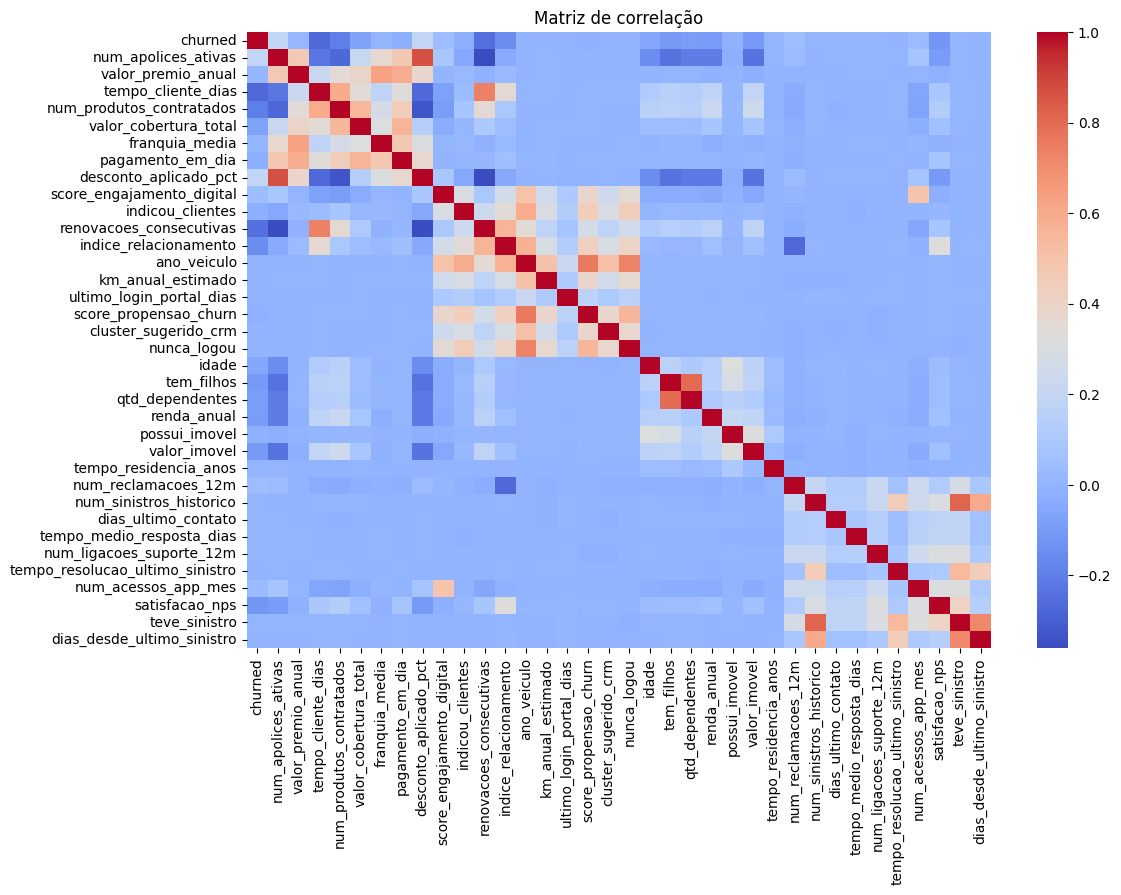

In [5]:
plt.figure(figsize=(12, 8))
# Correlaciona apenas as numéricas (o Pandas já ignora as categóricas no corr())
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap='coolwarm')
plt.title("Matriz de correlação")
plt.show()

In [10]:
df[[
    "num_apolices_ativas",
    "pagamento_em_dia",
    "apolices_x_pagamento",
    "churned"
]].corr()

,num_apolices_ativas,pagamento_em_dia,apolices_x_pagamento,churned
num_apolices_ativas,1.000000,0.472789,0.815314,0.193997
pagamento_em_dia,0.472789,1.000000,0.389519,-0.018563
apolices_x_pagamento,0.815314,0.389519,1.000000,0.174515
churned,0.193997,-0.018563,0.174515,1.000000


A partir da matriz de correlações, nota-se alguns pontos:
- num_apolices_ativas, desconto_aplicado_pct, num_produtos_contratados, renovacoes_consecutivas parecem ser as variáveis com maior relação com o churn
- desconto_aplicado_pct/num_apolices_ativas, score_propensao_churn/ano_veiculo, nunca_logou/ano_veiculo,  desconto_aplicado_pct/numero_produtos_contratados são colunas com correlações relevantes entre si
- a coluna de desconto_aplicado_pct parece ter correlação com muitas colunas
Outras hipóteses que vou investigar no futuro:
...

#### Features individuais
Vou analisar as distribuições e gráficos de features individuais tanto numéricas quanto categóricas

In [7]:
# Analisando como está a distribuição das variáveis numéricas contínuas

hist_num_cols = ["valor_premio_anual", "tempo_cliente_dias", "valor_cobertura_total", 
                 "franquia_media", "desconto_aplicado_pct", "score_engajamento_digital", 
                 "indice_relacionamento", "km_anual_estimado", "ultimo_login_portal_dias",
                 "score_propensao_churn", "renda_anual", "valor_imovel", "tempo_medio_resposta_dias", 
                 "tempo_resolucao_ultimo_sinistro", "num_acessos_app_mes"]

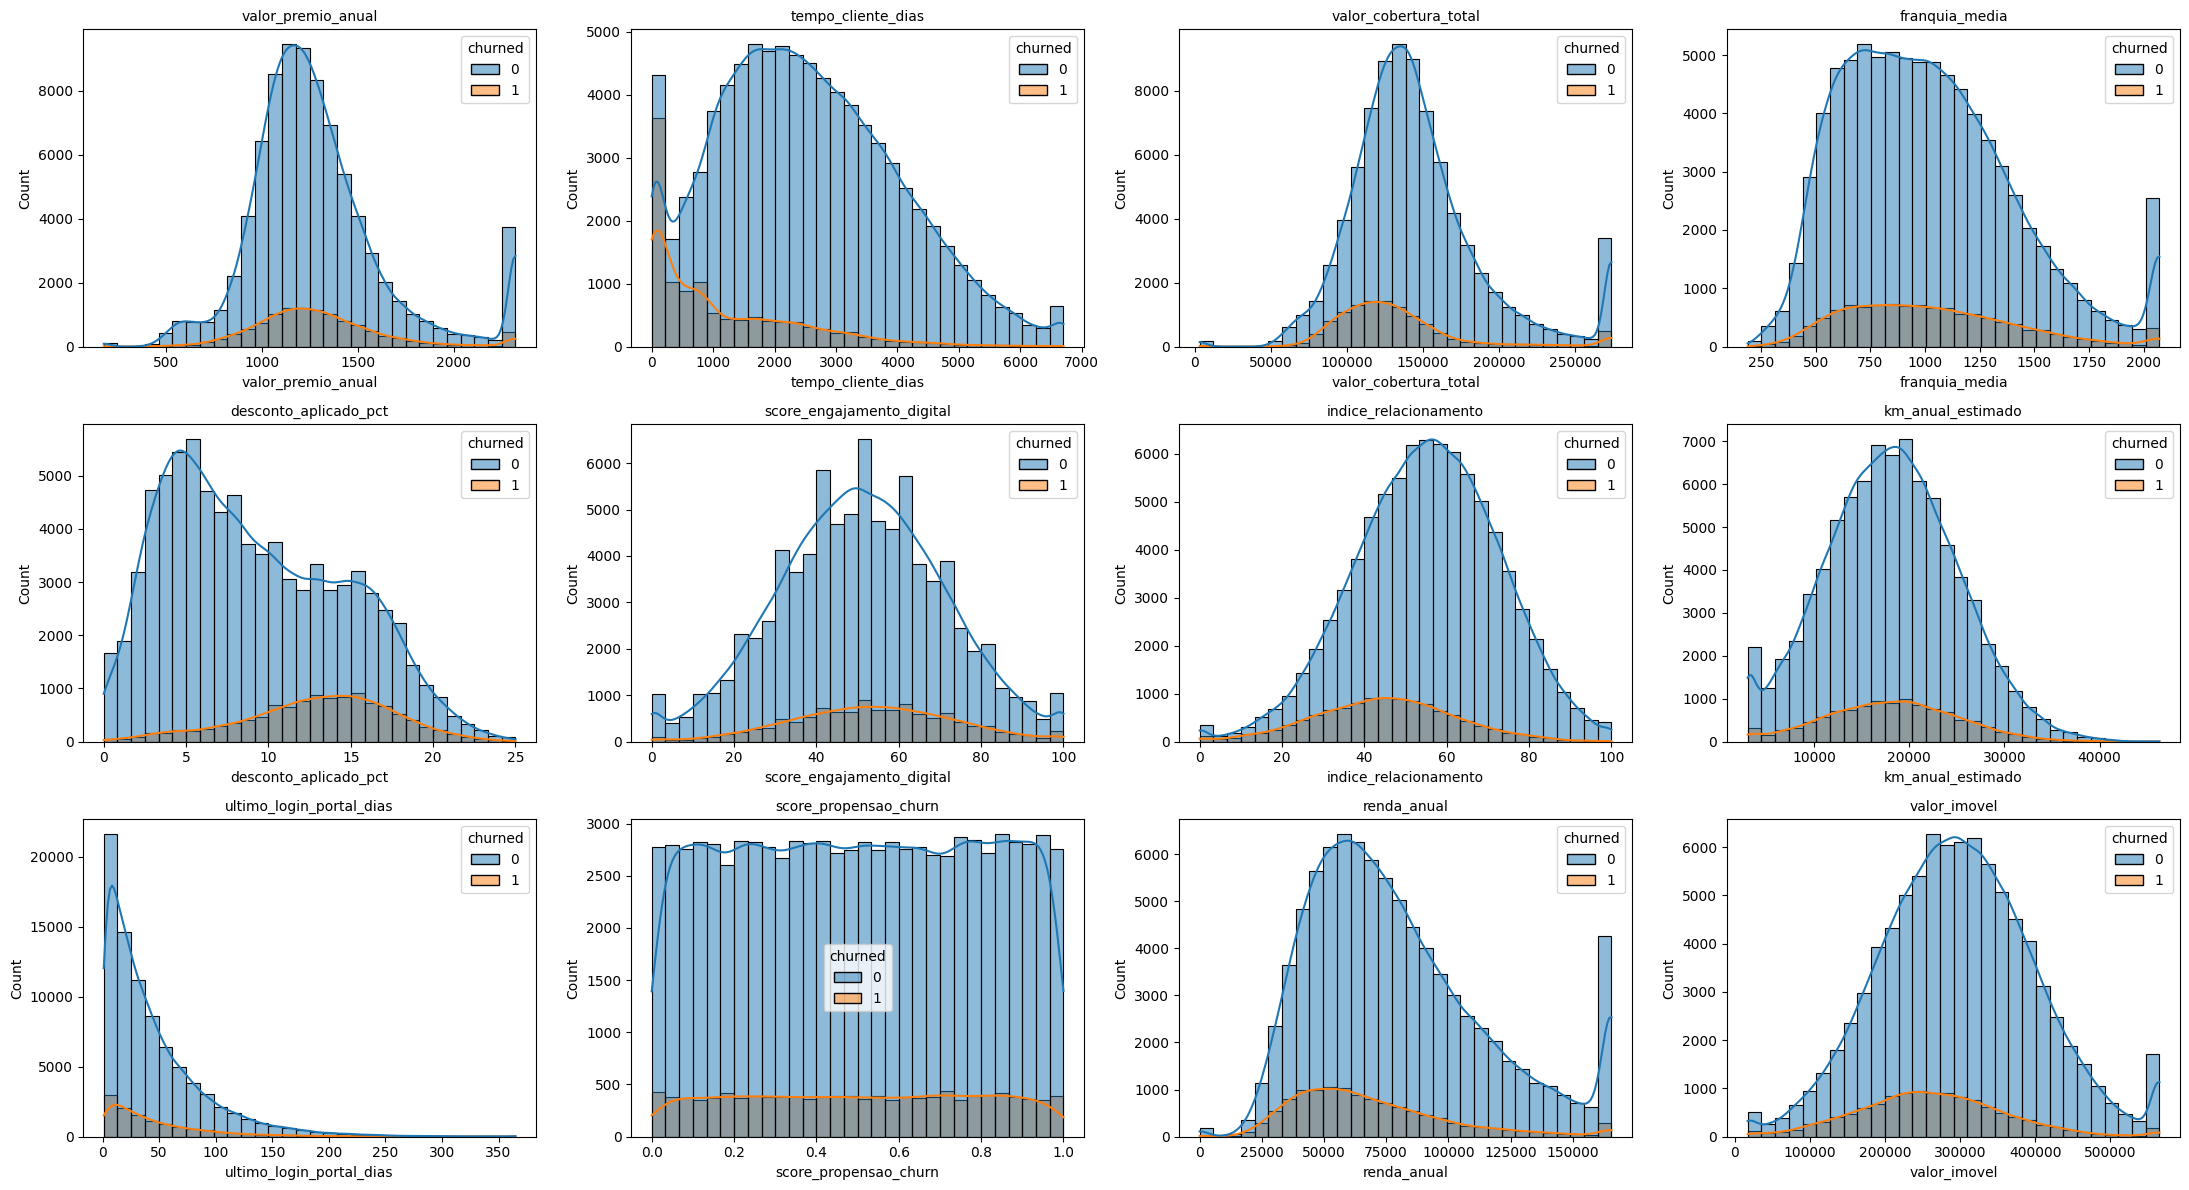

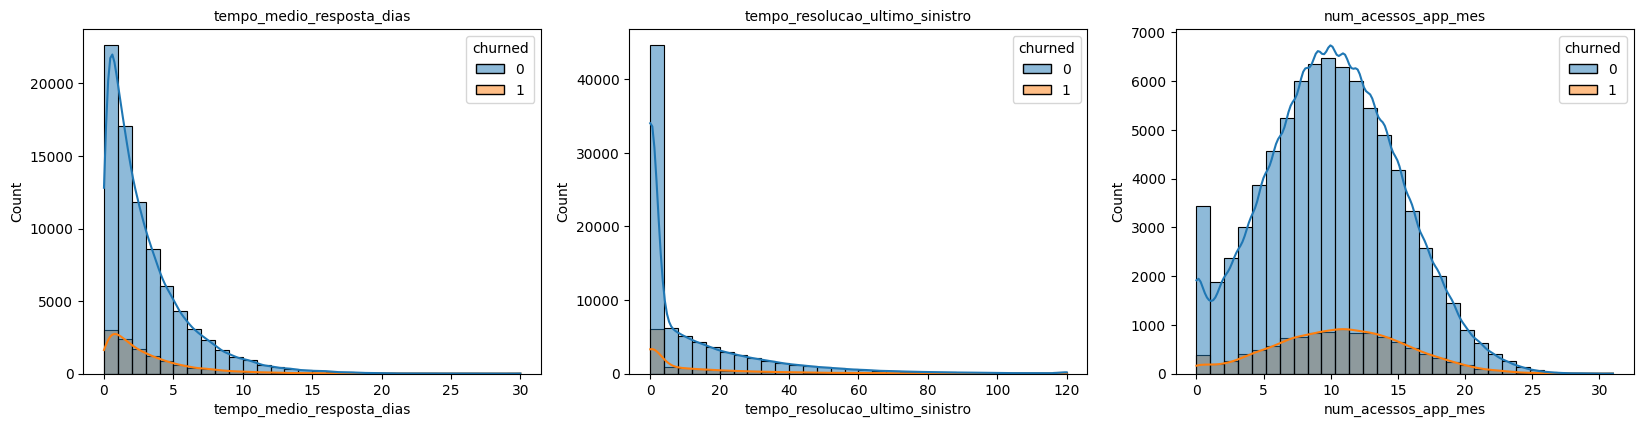

In [11]:
ncols = 4
nrows = 3


for inicio in range(0, len(hist_num_cols), nrows*ncols):

    cols_lote = hist_num_cols[inicio:inicio+nrows*ncols]

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(22, 12)
    )

    axes = axes.flatten()

    for ax, col in zip(axes, cols_lote):

        dados = df.loc[df[col] != -1, col]

        sns.histplot(
            data=df[df[col] != -1],
            x=col,
            hue="churned",
            kde=True,
            bins=30,
            ax=ax
        )

        ax.set_title(col, fontsize=10)

    for ax in axes[len(cols_lote):]:
        fig.delaxes(ax)

    plt.tight_layout()
    plt.show()

- valor_premio_anual, valor_cobertura_total, franquia_media, score_engajeamento_digital, indice_relacionamento, km_anual_estimado, renda_anual, valor_imovel  - apresentam distrubição aproximadamente normal.
- score_propensao_churn parece distribuida igualmente pra todos valores, exceto por um score de 0.5, que é dominantemente maior. Provavelmente é fruto da imputação por mediana
- ultimo_login_portal_dias, tempo_medio_resposta_dias, tempo_resolucao_ultimo_sinistro vão decrescendo exponencialmente
- PRT parece responder rapidamente os clientes 
- Desconto aplicado é predominantemente entre 5/10%.

C:\Users\rafag\AppData\Local\Temp\ipykernel_18360\2766808631.py:40: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#800020'` for the same effect.

  sns.countplot(
C:\Users\rafag\AppData\Local\Temp\ipykernel_18360\2766808631.py:40: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#800020'` for the same effect.

  sns.countplot(
C:\Users\rafag\AppData\Local\Temp\ipykernel_18360\2766808631.py:40: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#800020'` for the same effect.

  sns.countplot(
C:\Users\rafag\AppData\Local\Temp\ipykernel_18360\2766808631.py:40: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#800020'` for the same effect.

  sns.countplot(
C:\Users\rafag\AppData\Local\Temp\ipykernel_

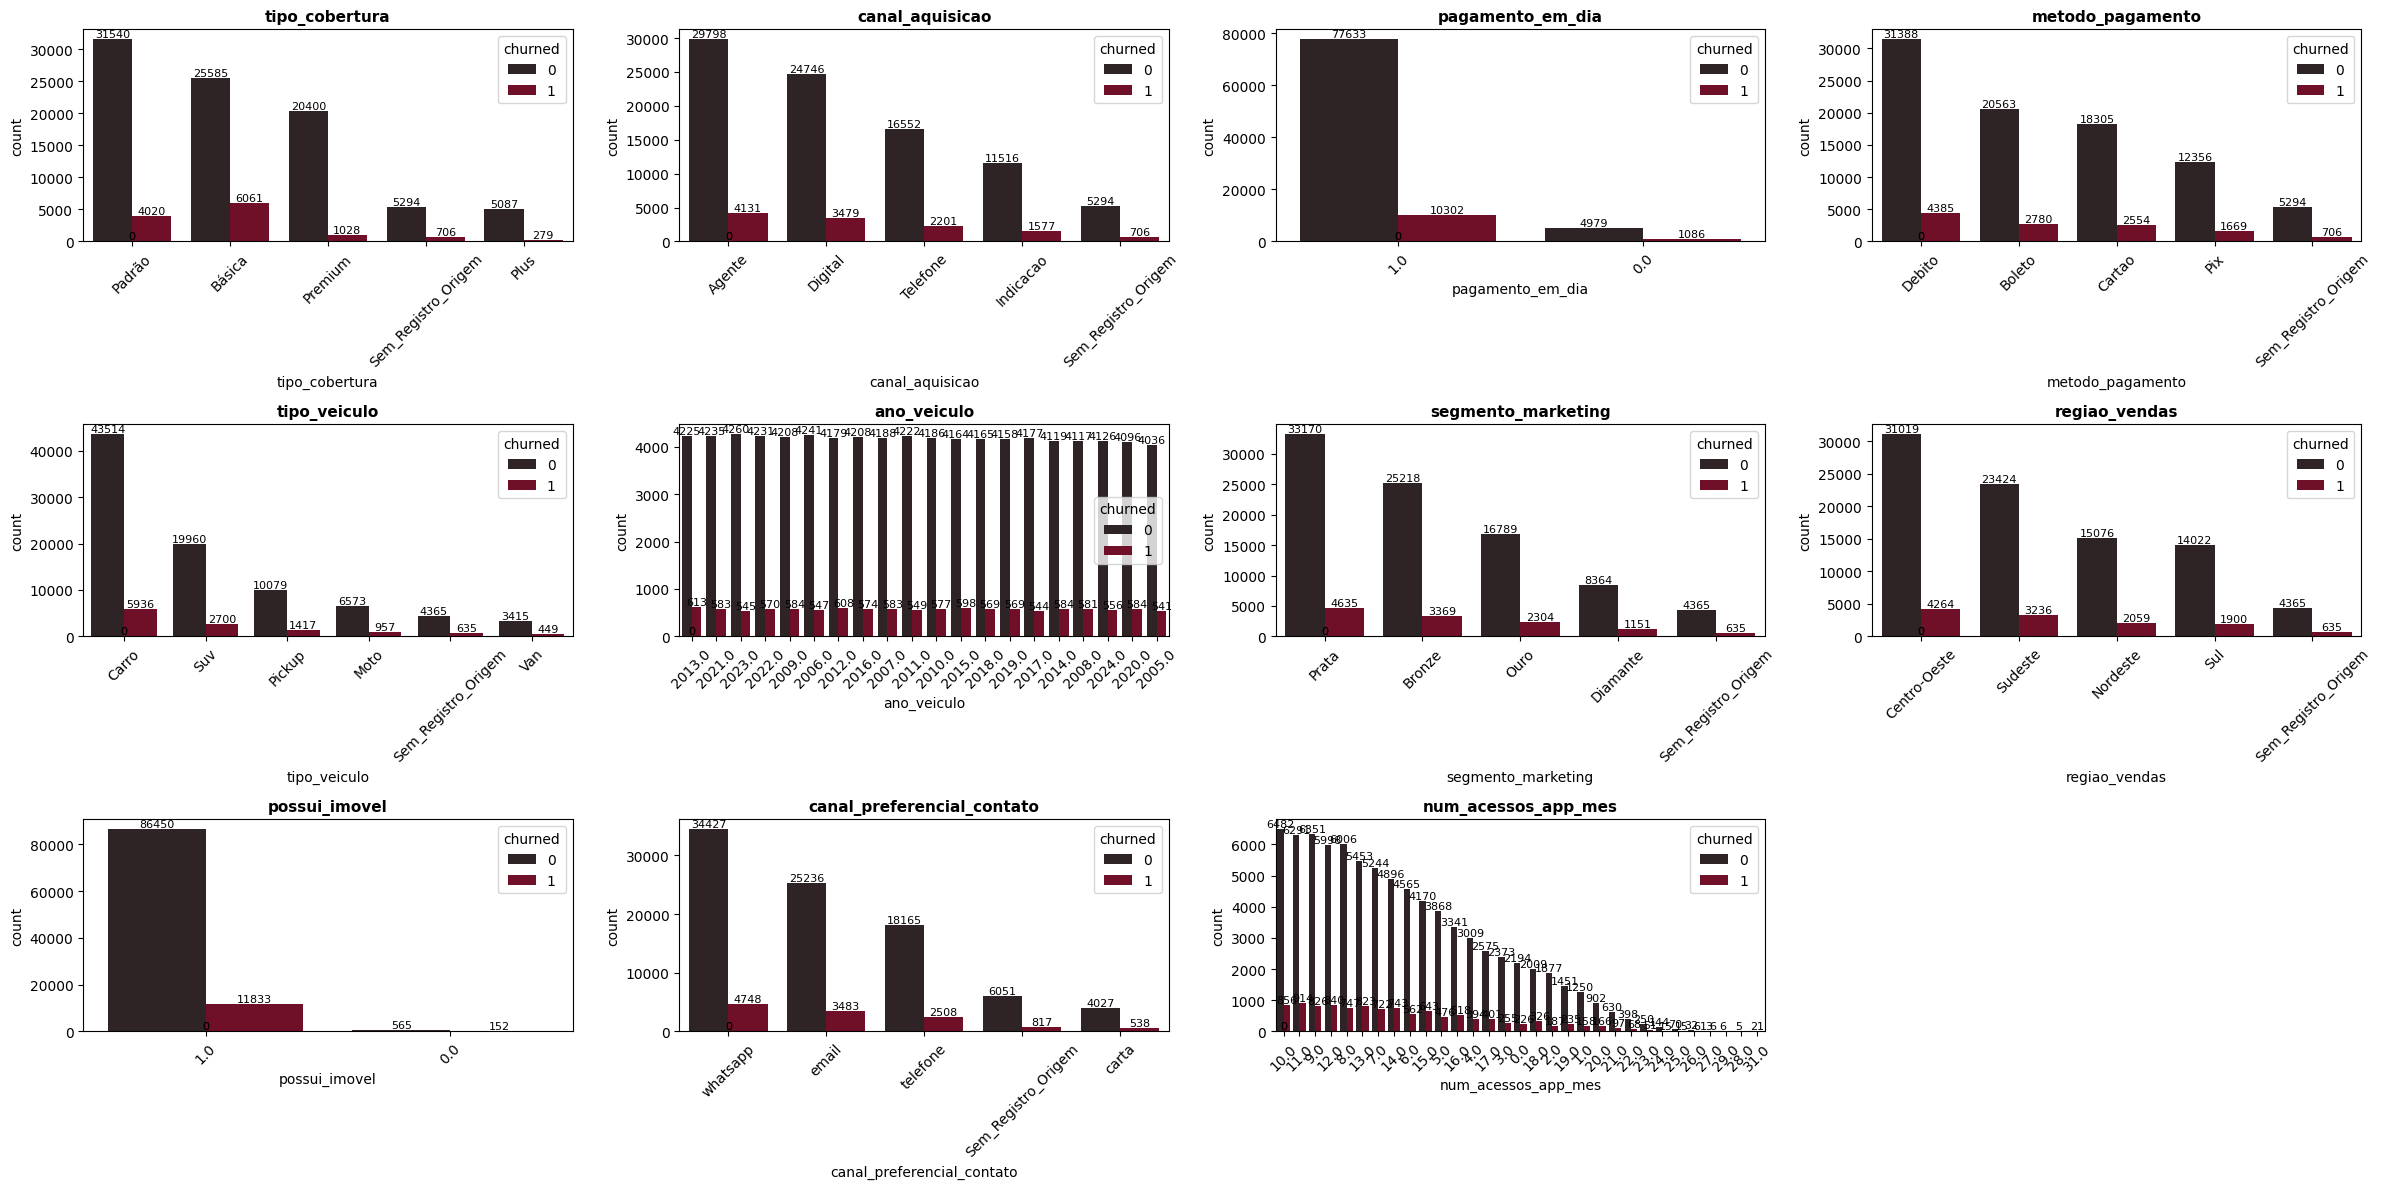

In [13]:
# Analisando distribuição das categóricas que parecem interessantes

countplot_cat = [
    "tipo_cobertura", "canal_aquisicao", "pagamento_em_dia", "metodo_pagamento", "tipo_veiculo",
    "ano_veiculo", "segmento_marketing", "regiao_vendas", "possui_imovel", "canal_preferencial_contato",
    "num_acessos_app_mes"
]
ncols = 4
nrows = 3

ncols = 4
nrows = 3

COR_VINHO = "#800020"

for inicio in range(0, len(countplot_cat), nrows * ncols):

    cols_lote = countplot_cat[inicio:inicio + nrows * ncols]

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(24, 12)
    )

    axes = axes.flatten()

    for ax, col in zip(axes, cols_lote):

        # remove os registros onde a coluna atual é -1
        dados = df[df[col] != -1]

        ordem = (
            dados[col]
            .astype(str)
            .value_counts()
            .index
        )

        sns.countplot(
            data=dados,
            x=col,
            order=ordem,
            color=COR_VINHO,
            ax=ax,
            hue="churned"
        )

        ax.set_title(
            col,
            fontsize=11,
            fontweight='bold'
        )

        ax.tick_params(
            axis='x',
            rotation=45
        )

        # Adiciona contagens acima das barras
        for p in ax.patches:

            altura = p.get_height()

            ax.annotate(
                f'{int(altura)}',
                (
                    p.get_x() + p.get_width() / 2,
                    altura
                ),
                ha='center',
                va='bottom',
                fontsize=8
            )

    # remove subplots vazios
    for ax in axes[len(cols_lote):]:
        fig.delaxes(ax)

    plt.tight_layout()
    plt.show()

- Cobertura padrão e básica as mais predominantes
- Maioria chegou ao seguro via agente
- Maioria paga via débito, depois boleto e cartão. (boleto estar em segundo é surpreendente)
- Carro é a categoria predominante de veículo com seguro. Pouquíssimas vans
- A grande maioria possui imóvel
- Whatsapp é o canal preferido, depois email

#### Correlação entre features
Analisarei corelações entre diferentes features e suas relações com o churn.

In [11]:
df.columns

Index(['id_cliente', 'churned', 'num_apolices_ativas', 'tipo_cobertura',
       'valor_premio_anual', 'tempo_cliente_dias', 'data_primeira_apolice',
       'num_produtos_contratados', 'valor_cobertura_total', 'franquia_media',
       'canal_aquisicao', 'pagamento_em_dia', 'desconto_aplicado_pct',
       'metodo_pagamento', 'score_engajamento_digital', 'indicou_clientes',
       'renovacoes_consecutivas', 'indice_relacionamento', 'tipo_veiculo',
       'ano_veiculo', 'km_anual_estimado', 'segmento_marketing',
       'regiao_vendas', 'ultimo_login_portal_dias', 'score_propensao_churn',
       'cluster_sugerido_crm', 'nunca_logou', 'idade', 'genero',
       'estado_civil', 'tem_filhos', 'qtd_dependentes', 'escolaridade',
       'renda_anual', 'possui_imovel', 'valor_imovel', 'tempo_residencia_anos',
       'num_reclamacoes_12m', 'num_sinistros_historico', 'dias_ultimo_contato',
       'canal_preferencial_contato', 'tempo_medio_resposta_dias',
       'num_ligacoes_suporte_12m', 'tempo_reso

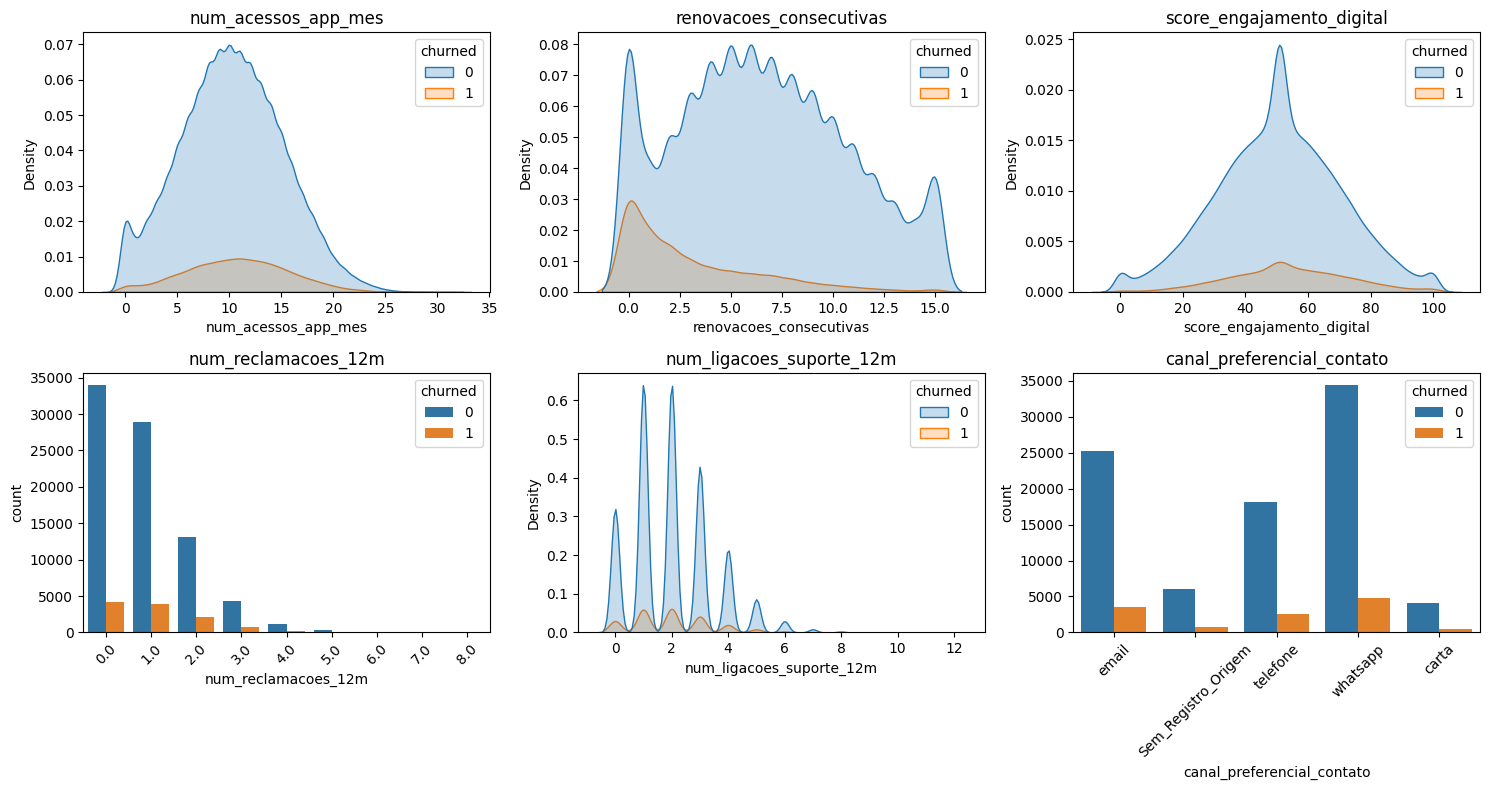

In [12]:
# Churn x variáveis comportamentais
comp_cols = [
    "num_acessos_app_mes",
    "renovacoes_consecutivas",
    "score_engajamento_digital",
    "num_reclamacoes_12m",
    "num_ligacoes_suporte_12m",
    "canal_preferencial_contato"
]

n_cols = 3
n_rows = math.ceil(len(comp_cols) / n_cols)

plt.figure(figsize=(n_cols * 5, n_rows * 4))

for i, col in enumerate(comp_cols):
    plt.subplot(n_rows, n_cols, i + 1)

    # remove apenas os registros com -1 na coluna atual
    dados = df[df[col] != -1]

    if dados[col].dtype == "object" or dados[col].nunique() < 10:
        sns.countplot(
            data=dados,
            x=col,
            hue="churned"
        )
        plt.xticks(rotation=45)
    else:
        sns.kdeplot(
            data=dados,
            x=col,
            hue="churned",
            fill=True
        )

    plt.title(col)

plt.tight_layout()
plt.show()

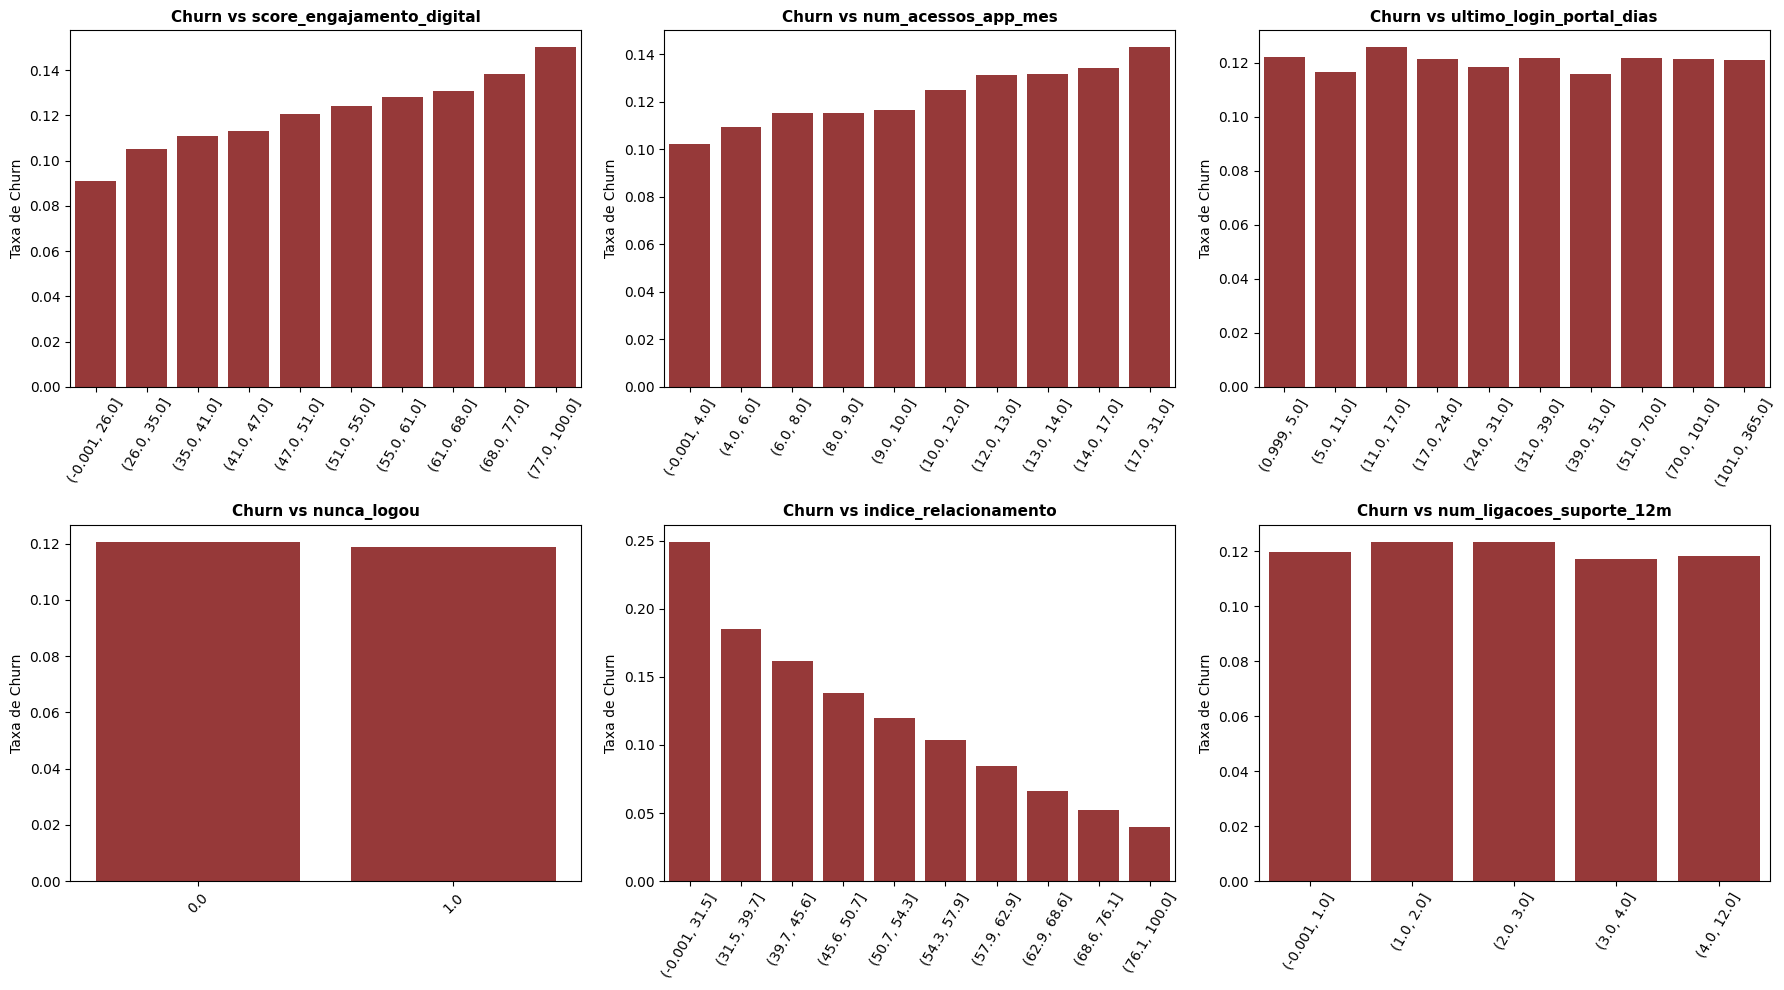

In [13]:
engajamento_cols = [
    "score_engajamento_digital",
    "num_acessos_app_mes",
    "ultimo_login_portal_dias",
    "nunca_logou",
    "indice_relacionamento",
    "num_ligacoes_suporte_12m",
]

ncols = 3
nrows = math.ceil(len(engajamento_cols) / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(18, 5 * nrows)
)

axes = axes.flatten()

for ax, col in zip(axes, engajamento_cols):

    dados = df[df[col] != -1].copy()

    # variável categórica/binária
    if (
        dados[col].dtype == "object"
        or dados[col].nunique() <= 10
    ):

        taxa = (
            dados
            .groupby(col)["churned"]
            .mean()
            .reset_index()
            .sort_values("churned", ascending=False)
        )

        sns.barplot(
            data=taxa,
            x=col,
            y="churned",
            color="brown",
            ax=ax
        )

        ax.tick_params(axis="x", rotation=45)

    # variável numérica
    else:

        dados["faixa"] = pd.qcut(
            dados[col],
            q=10,
            duplicates="drop"
        )

        taxa = (
            dados
            .groupby("faixa", observed=False)["churned"]
            .mean()
            .reset_index()
        )

        sns.barplot(
            data=taxa,
            x="faixa",
            y="churned",
            color="brown",
            ax=ax
        )

        ax.tick_params(
            axis="x",
            rotation=60
        )

    ax.set_title(
        f"Churn vs {col}",
        fontsize=11,
        fontweight="bold"
    )

    ax.set_ylabel("Taxa de Churn")
    ax.set_xlabel("")

for ax in axes[len(engajamento_cols):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

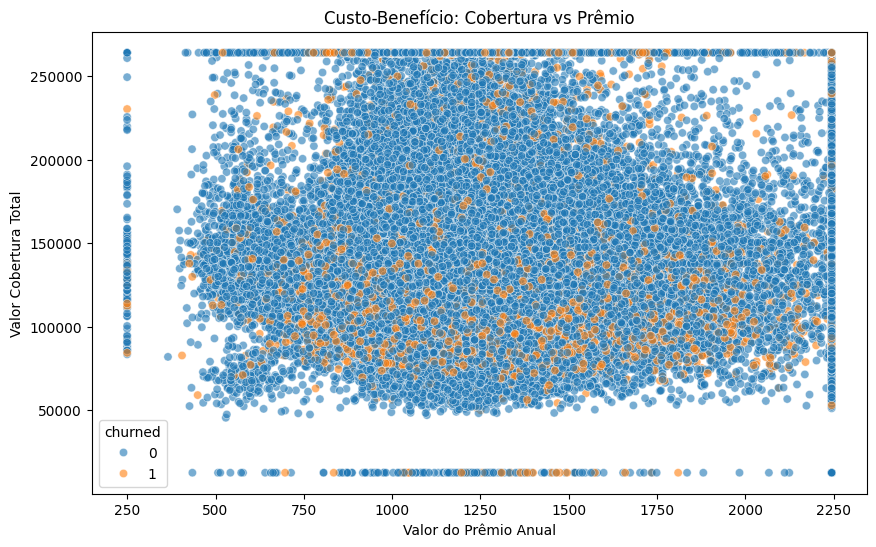

In [16]:
# Relação custo x benefício

df_churn = df[df["valor_cobertura_total"] != -1].copy()

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_churn,
    x="valor_premio_anual",
    y="valor_cobertura_total",
    hue="churned",
    alpha=0.6
)

plt.title("Custo-Benefício: Cobertura vs Prêmio")
plt.xlabel("Valor do Prêmio Anual")
plt.ylabel("Valor Cobertura Total")

plt.show()

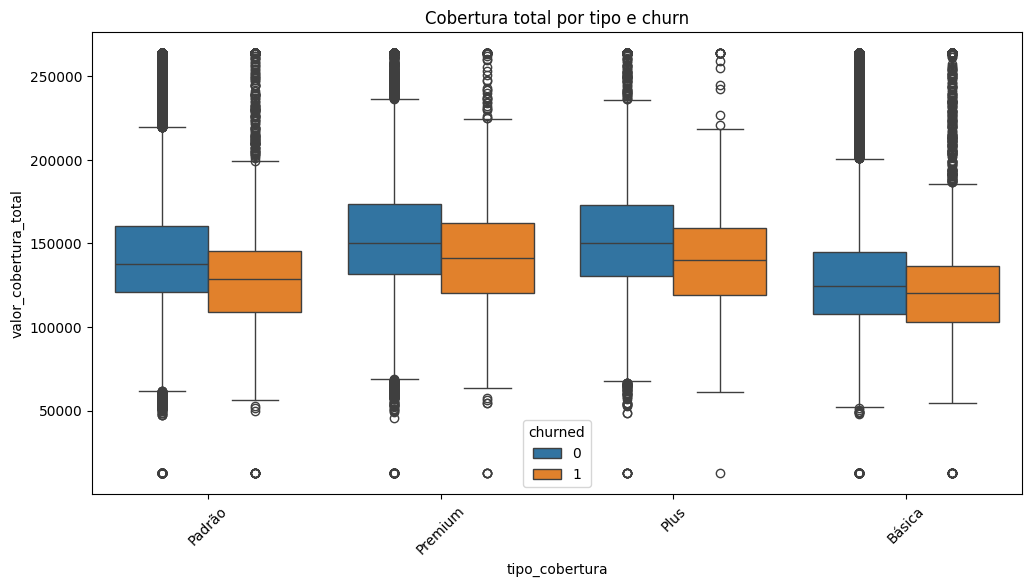

In [18]:
# Churn por tipo de cobertura, valor de cobertura
df_churn = df[df["valor_cobertura_total"] != -1].copy()

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_churn,
    x="tipo_cobertura",
    y="valor_cobertura_total",
    hue="churned"
)

plt.xticks(rotation=45)
plt.title("Cobertura total por tipo e churn")

plt.show()

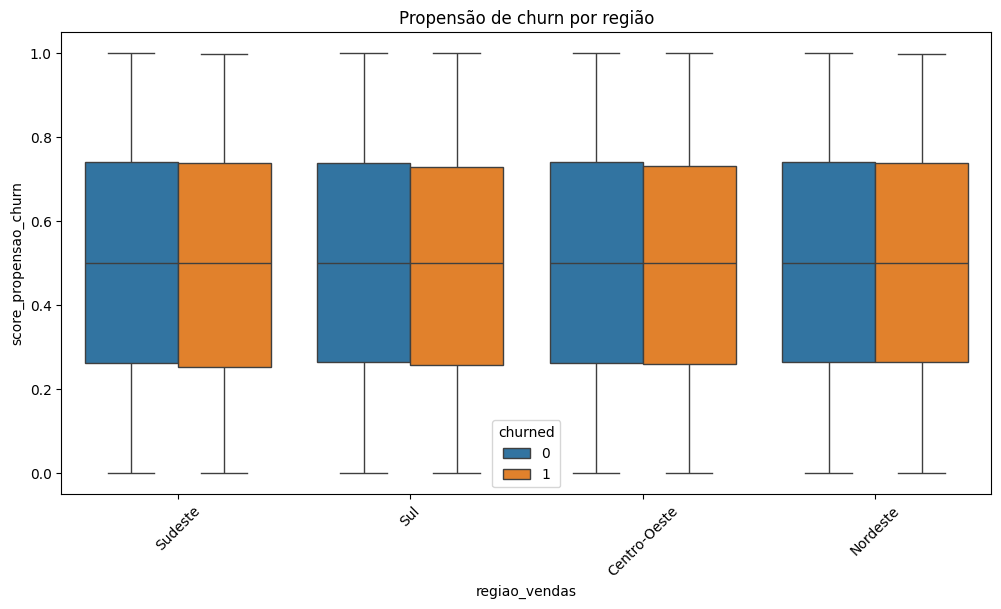

In [22]:
df_churn = df[df["score_propensao_churn"] != -1].copy()
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_churn,
    x="regiao_vendas",
    y="score_propensao_churn",
    hue="churned"
)

plt.xticks(rotation=45)
plt.title("Propensão de churn por região")

plt.show()

C:\Users\rafag\AppData\Local\Temp\ipykernel_7740\2966169199.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_analise, x='churned', y='ratio_premio_cobertura', palette='Set2', ax=axes[0])
C:\Users\rafag\AppData\Local\Temp\ipykernel_7740\2966169199.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_analise, x='churned', y='idade_veiculo_anos', palette='Set3', ax=axes[1])
C:\Users\rafag\AppData\Local\Temp\ipykernel_7740\2966169199.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=resumo_friccao, x='friccao_pagament

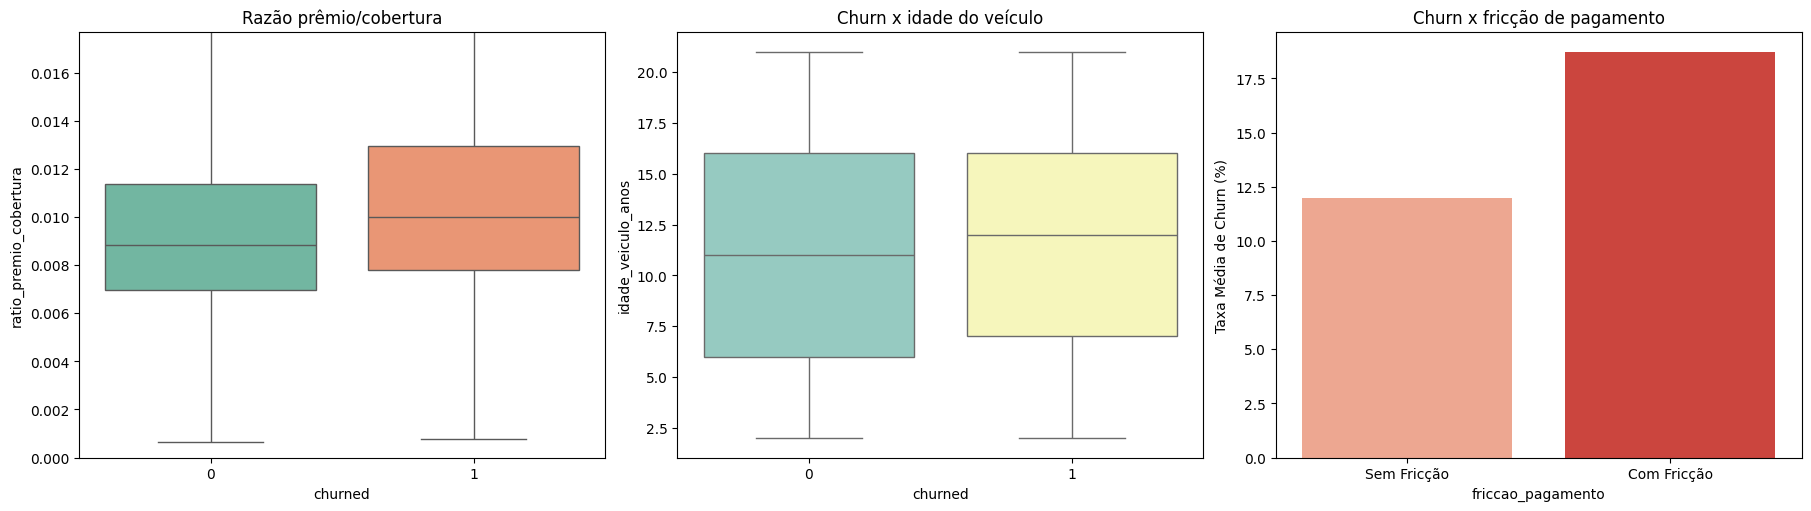

In [6]:
# Hipóteses de fatores que podem influenciar o churn
# relação custo-benefício, idade do veículo, situação de pagamento irregular  

# 1. Cópia segura e filtro de valores negativos
df_analise = df.copy()

# Filtra removendo qualquer linha que tenha valor < 0 nas colunas numéricas (exclui os -1)
colunas_numericas = df_analise.select_dtypes(include=['int64', 'float64']).columns
for col in colunas_numericas:
    df_analise = df_analise[df_analise[col] >= 0]

# 2. Construção das Features
ano_referencia = 2026 # Ajuste para o ano atual da sua base
df_analise['ratio_premio_cobertura'] = df_analise['valor_premio_anual'] / (df_analise['valor_cobertura_total'])
df_analise['idade_veiculo_anos'] = ano_referencia - df_analise['ano_veiculo']
df_analise['friccao_pagamento'] = ((df_analise['metodo_pagamento'].str.lower() == 'boleto') & 
                                   (df_analise['pagamento_em_dia'] == 0)).astype(int)

# 3. Visualização (Painel 1x3)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

# Gráfico A: Pressão Financeira (Ratio)
sns.boxplot(data=df_analise, x='churned', y='ratio_premio_cobertura', palette='Set2', ax=axes[0])
axes[0].set_title('Razão prêmio/cobertura')
axes[0].set_ylim(0, df_analise['ratio_premio_cobertura'].quantile(0.95)) # Corta outliers extremos para visualização

# Gráfico B: Desgaste do Bem (Idade do Veículo)
sns.boxplot(data=df_analise, x='churned', y='idade_veiculo_anos', palette='Set3', ax=axes[1])
axes[1].set_title('Churn x idade do veículo')

# Gráfico C: Fricção de Pagamento
resumo_friccao = df_analise.groupby('friccao_pagamento')['churned'].mean().mul(100).round(2).reset_index()
sns.barplot(data=resumo_friccao, x='friccao_pagamento', y='churned', palette='Reds', ax=axes[2])
axes[2].set_title('Churn x fricção de pagamento')
axes[2].set_xticklabels(['Sem Fricção', 'Com Fricção'])
axes[2].set_ylabel('Taxa Média de Churn (%)')

plt.show()

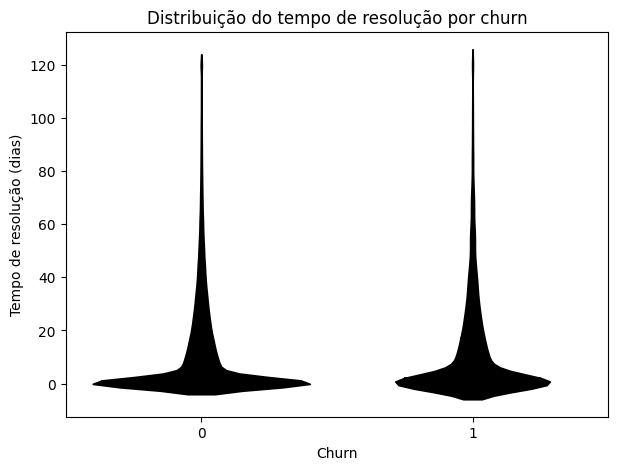

In [29]:
plt.figure(figsize=(7,5))

sns.violinplot(
    data=dados,
    x="churned",
    y="tempo_resolucao_ultimo_sinistro",
    inner="quartile",
    fill=True,
    color="black"
)

plt.title("Distribuição do tempo de resolução por churn")
plt.xlabel("Churn")
plt.ylabel("Tempo de resolução (dias)")

plt.show()

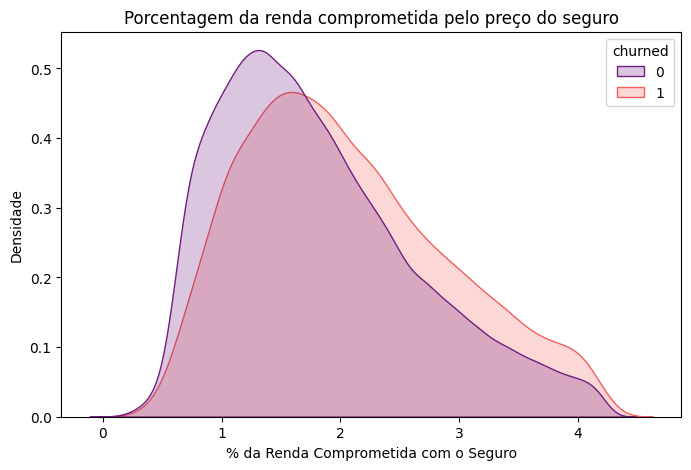

In [33]:
# Criando cópia e garantindo que renda seja maior que zero para evitar divisão por zero
df_teste_h2 = df[df['renda_anual'] > 0 ].copy()
df_teste_h2 = df_teste_h2[df_teste_h2['valor_premio_anual'] > 0 ]

# Feature: Comprometimento da Renda (%)
df_teste_h2['impacto_renda_pct'] = (df_teste_h2['valor_premio_anual'] / df_teste_h2['renda_anual']) * 100

# Removendo outliers extremos de renda para visualização limpa
limite_superior = df_teste_h2['impacto_renda_pct'].quantile(0.95)
df_teste_h2 = df_teste_h2[df_teste_h2['impacto_renda_pct'] <= limite_superior]

# Visualização
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df_teste_h2, x='impacto_renda_pct', hue='churned', common_norm=False, fill=True, palette='magma')
plt.title('Porcentagem da renda comprometida pelo preço do seguro')
plt.xlabel('% da Renda Comprometida com o Seguro')
plt.ylabel('Densidade')
plt.show()

C:\Users\rafag\AppData\Local\Temp\ipykernel_7740\2168853214.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=resumo_h3, x='perfil_desconto', y='churned', palette='viridis')


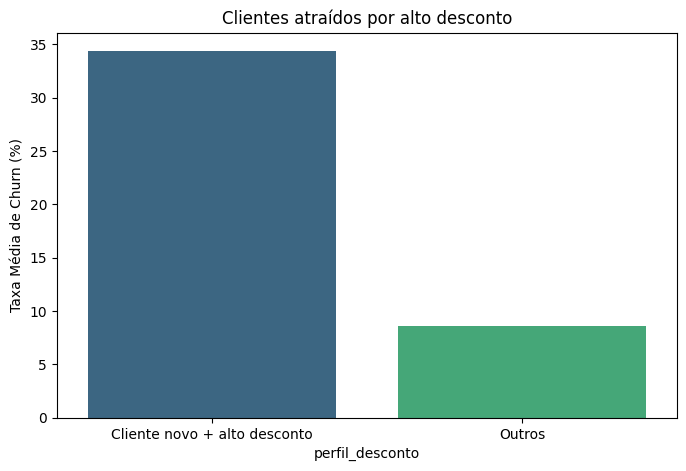

In [7]:
df_teste_h3 = df.copy()

media_desc = df_teste_h3["desconto_aplicado_pct"].mean()

# Features: Isolando novatos e definindo o que é um "Alto Desconto"
df_teste_h3['cliente_novato'] = df_teste_h3['renovacoes_consecutivas'] <= 1
df_teste_h3['alto_desconto'] = df_teste_h3['desconto_aplicado_pct'] > media_desc

# Cruzamento: Novatos com Alto Desconto vs. Outros
df_teste_h3['perfil_desconto'] = 'Outros'
mask_mercenario = df_teste_h3['cliente_novato'] & df_teste_h3['alto_desconto']
df_teste_h3.loc[mask_mercenario, 'perfil_desconto'] = 'Cliente novo + alto desconto'

# Tabela de frequências agregada
resumo_h3 = df_teste_h3.groupby('perfil_desconto')['churned'].mean().mul(100).round(2).reset_index()

# Visualização
plt.figure(figsize=(8, 5))
sns.barplot(data=resumo_h3, x='perfil_desconto', y='churned', palette='viridis')
plt.title('Clientes atraídos por alto desconto')
plt.ylabel('Taxa Média de Churn (%)')
plt.show()

In [11]:
len(df_teste_h3[df_teste_h3['perfil_desconto'] != 'Outros'])

13679

C:\Users\rafag\AppData\Local\Temp\ipykernel_7740\2636803741.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=resumo_h5, x='risco_silencioso', y='churned', palette='dark:salmon')


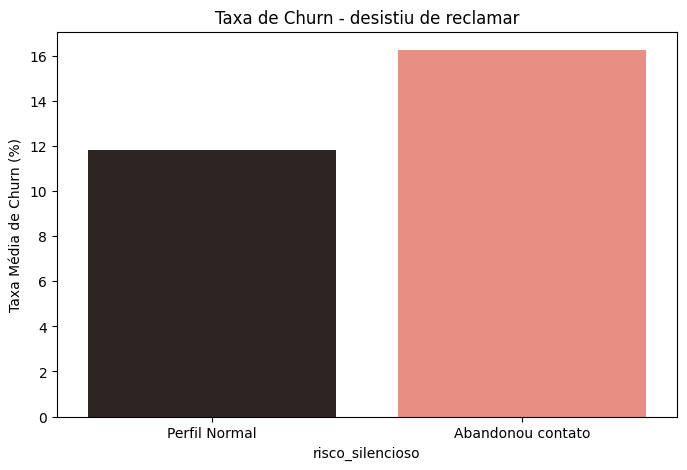

In [14]:
# Isolando apenas clientes que já responderam NPS e têm registro válido de dias de contato
df_teste_h5 = df[(df['satisfacao_nps'] >= 0) & (df['dias_ultimo_contato'] >= 0)].copy()

# Feature: Flag de Risco Silencioso
# Reclamou E sumiu (mais de 90 dias) E deu nota de detrator (NPS <= 6)
df_teste_h5['risco_silencioso'] = (
    (df_teste_h5['num_reclamacoes_12m'] > 0) & 
    (df_teste_h5['dias_ultimo_contato'] > 90) & 
    (df_teste_h5['satisfacao_nps'] <= 6)
).astype(int)

resumo_h5 = df_teste_h5.groupby('risco_silencioso')['churned'].mean().mul(100).round(2).reset_index()

# Visualização
plt.figure(figsize=(8, 5))
sns.barplot(data=resumo_h5, x='risco_silencioso', y='churned', palette='dark:salmon')
plt.title('Taxa de Churn - desistiu de reclamar')
plt.xticks(ticks=[0, 1], labels=['Perfil Normal', 'Abandonou contato'])
plt.ylabel('Taxa Média de Churn (%)')
plt.show()

In [16]:
len(df_teste_h5[df_teste_h5["risco_silencioso"] == 1])

6308

In [ ]:
### ANALISAR CLIENTES COM DADOS FALTANTES EM ALGUMA BASE COMO UM GRUPO E ANALISAR AS RELACOES DESSES CARAS

C:\Users\rafag\AppData\Local\Temp\ipykernel_22092\3665859227.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


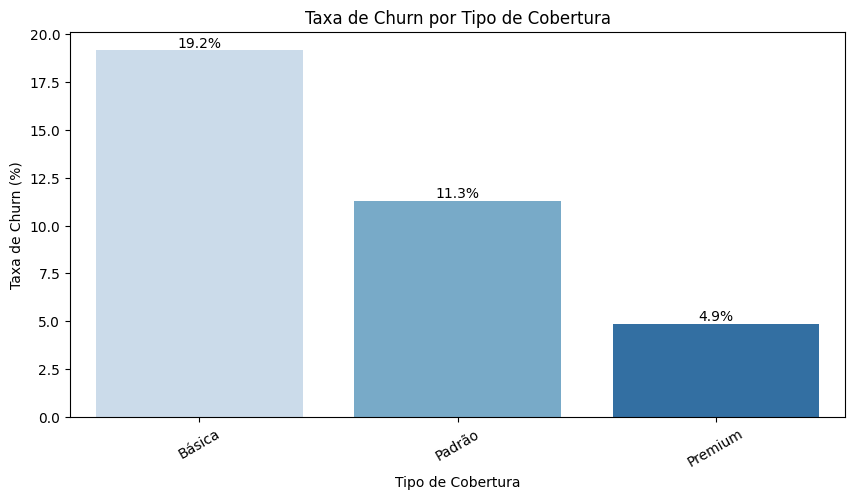

In [4]:
plt.figure(figsize=(10, 5))

df_cat = df.copy()
df_cat = df_cat[df_cat["tipo_cobertura"] != "Sem_Registro_Origem"]

resumo_h1 = (
    df_cat.groupby('tipo_cobertura')['churned']
    .mean()
    .mul(100)
    .reset_index()
    .sort_values('churned', ascending=False)
)

sns.barplot(
    data=resumo_h1,
    x='tipo_cobertura',
    y='churned',
    palette='Blues'
)

plt.title('Taxa de Churn por Tipo de Cobertura')
plt.ylabel('Taxa de Churn (%)')
plt.xlabel('Tipo de Cobertura')
plt.xticks(rotation=30)

# opcional: rótulos nas barras
for p in plt.gca().patches:
    altura = p.get_height()
    plt.gca().annotate(
        f'{altura:.1f}%',
        (p.get_x() + p.get_width()/2, altura),
        ha='center',
        va='bottom'
    )

plt.show()

C:\Users\rafag\AppData\Local\Temp\ipykernel_18360\3635172507.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=resumo_churn, x='eh_fantasma', y='churned', palette='Reds', ax=axes[0, 0])
C:\Users\rafag\AppData\Local\Temp\ipykernel_18360\3635172507.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=resumo_canal, x='canal_aquisicao', y='eh_fantasma', palette='Set2', ax=axes[0, 1])
C:\Users\rafag\AppData\Local\Temp\ipykernel_18360\3635172507.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_veiculo_valido, x='eh_fantasm

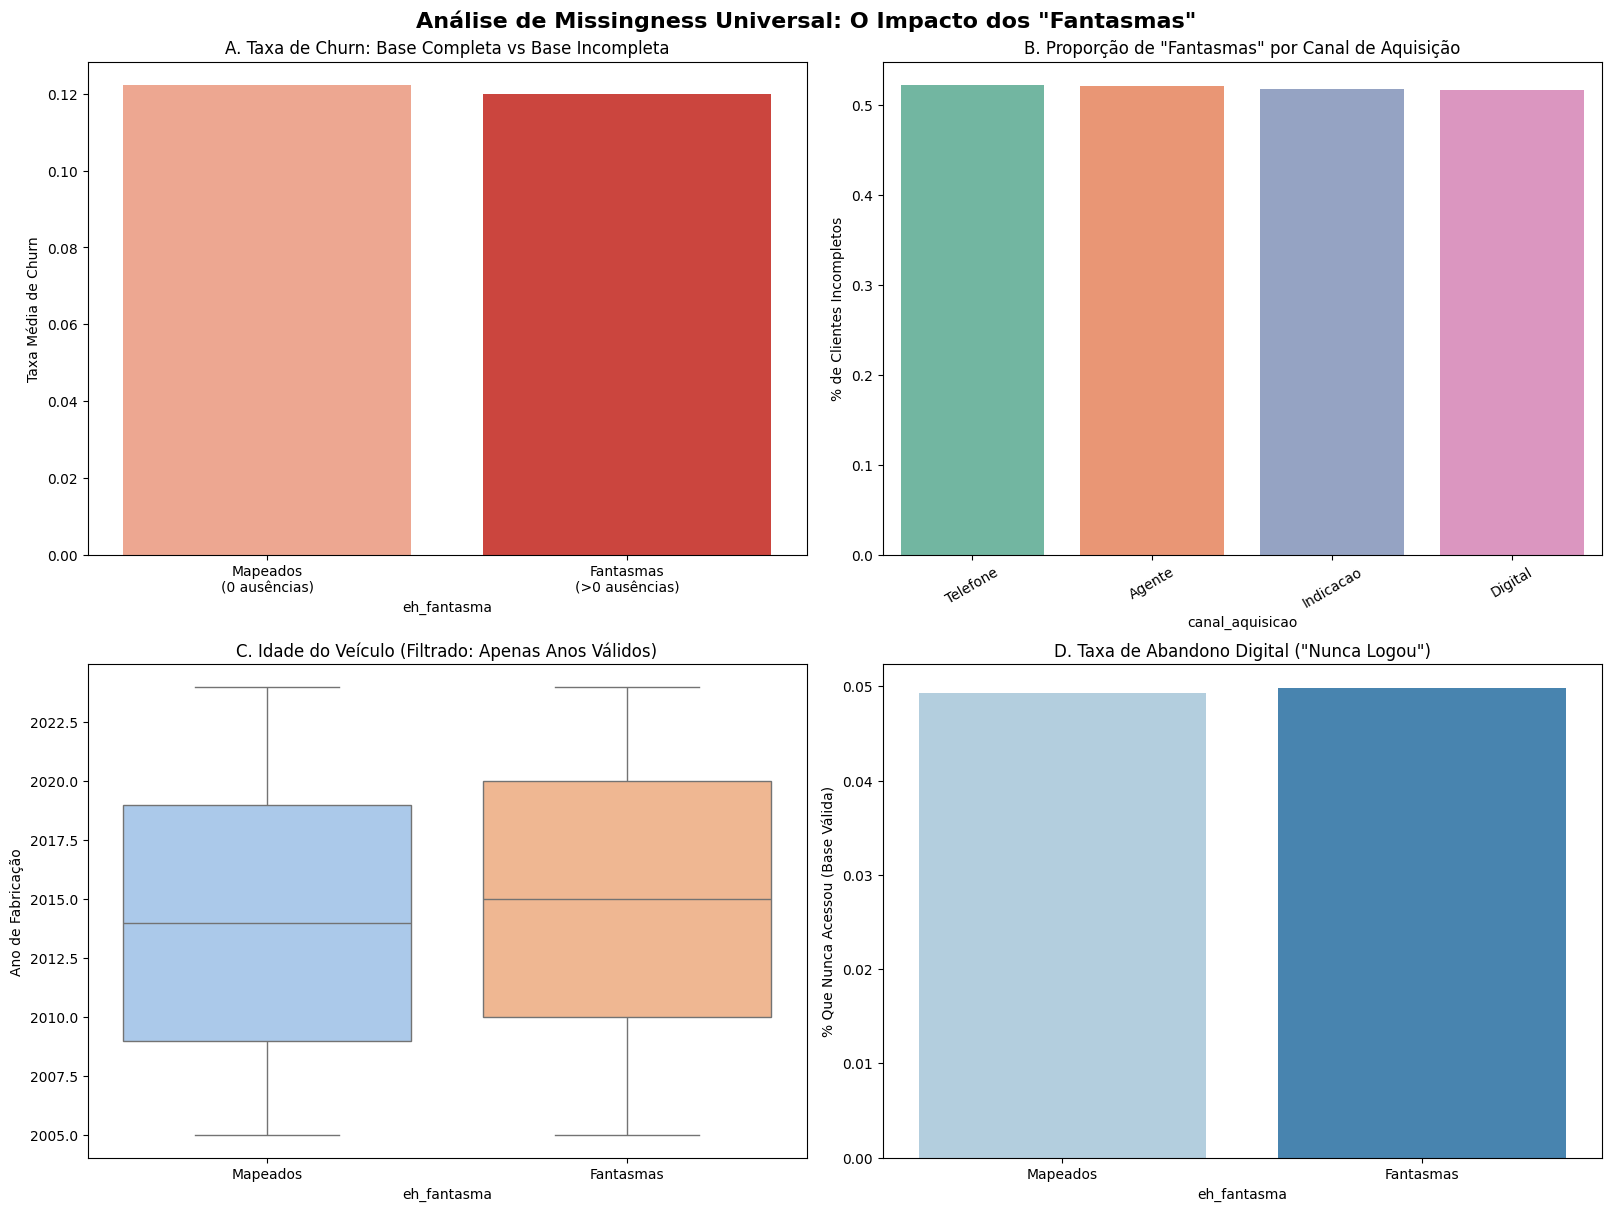

In [33]:

# 1. Cópia segura
df_miss = df.copy()

# ==========================================
# FEATURE ENGINEERING: IDENTIFICANDO O "FANTASMA" GERAL
# ==========================================

# Varre TODAS as colunas numéricas procurando por -1
mask_num = (df_miss.select_dtypes(include=[np.number]) == -1)

# Varre TODAS as colunas categóricas (texto) procurando por sua string de imputação
mask_cat = df_miss.select_dtypes(exclude=[np.number]).apply(
    lambda col: col.astype(str).str.contains('Sem_registro', case=False, na=False)
)

# Soma a quantidade de "buracos" imputados que cada cliente (linha) possui
df_miss['qtd_dados_ausentes'] = mask_num.sum(axis=1) + mask_cat.sum(axis=1)

# Define como "Fantasma" o cliente que possui pelo menos 1 marcação de ausência
df_miss['eh_fantasma'] = (df_miss['qtd_dados_ausentes'] > 0).astype(int)

# ==========================================
# PREPARAÇÃO PARA GRÁFICOS (Esvaziando o lixo matemático)
# ==========================================
# Para analisar o perfil sem que o -1 destrua a média/distribuição, 
# criamos visões filtradas apenas para as colunas plotadas:

df_veiculo_valido = df_miss[df_miss['ano_veiculo'] > 0]
df_login_valido = df_miss[df_miss['nunca_logou'] >= 0]
df_canal_valido = df_miss[~df_miss['canal_aquisicao'].astype(str).str.contains('Sem_registro', case=False, na=False)]

# ==========================================
# VISUALIZAÇÕES EM GRID (2x2)
# ==========================================
# Usando constrained_layout para garantir que textos não se sobreponham
fig, axes = plt.subplots(2, 2, figsize=(16, 12), constrained_layout=True)
fig.suptitle('Análise de Missingness Universal: O Impacto dos "Fantasmas"', fontsize=16, fontweight='bold')

# --- GRÁFICO A: Impacto direto no Churn ---
resumo_churn = df_miss.groupby('eh_fantasma')['churned'].mean().reset_index()
sns.barplot(data=resumo_churn, x='eh_fantasma', y='churned', palette='Reds', ax=axes[0, 0])
axes[0, 0].set_title('A. Taxa de Churn: Base Completa vs Base Incompleta')
axes[0, 0].set_xticks([0, 1])
axes[0, 0].set_xticklabels(['Mapeados\n(0 ausências)', 'Fantasmas\n(>0 ausências)'])
axes[0, 0].set_ylabel('Taxa Média de Churn')

# --- GRÁFICO B: A Origem do Problema (Por Canal) ---
# Mostra a % de fantasmas dentro de cada canal válido
resumo_canal = df_canal_valido.groupby('canal_aquisicao')['eh_fantasma'].mean().reset_index().sort_values('eh_fantasma', ascending=False)
sns.barplot(data=resumo_canal, x='canal_aquisicao', y='eh_fantasma', palette='Set2', ax=axes[0, 1])
axes[0, 1].set_title('B. Proporção de "Fantasmas" por Canal de Aquisição')
axes[0, 1].set_ylabel('% de Clientes Incompletos')
axes[0, 1].tick_params(axis='x', rotation=30)

# --- GRÁFICO C: Perfil do Veículo (Removendo os -1) ---
sns.boxplot(data=df_veiculo_valido, x='eh_fantasma', y='ano_veiculo', palette='pastel', ax=axes[1, 0])
axes[1, 0].set_title('C. Idade do Veículo (Filtrado: Apenas Anos Válidos)')
axes[1, 0].set_xticks([0, 1])
axes[1, 0].set_xticklabels(['Mapeados', 'Fantasmas'])
axes[1, 0].set_ylabel('Ano de Fabricação')

# --- GRÁFICO D: O Abismo Digital (Removendo os -1) ---
resumo_login = df_login_valido.groupby('eh_fantasma')['nunca_logou'].mean().reset_index()
sns.barplot(data=resumo_login, x='eh_fantasma', y='nunca_logou', palette='Blues', ax=axes[1, 1])
axes[1, 1].set_title('D. Taxa de Abandono Digital ("Nunca Logou")')
axes[1, 1].set_xticks([0, 1])
axes[1, 1].set_xticklabels(['Mapeados', 'Fantasmas'])
axes[1, 1].set_ylabel('% Que Nunca Acessou (Base Válida)')

plt.show()

In [4]:
df.columns

Index(['id_cliente', 'churned', 'num_apolices_ativas', 'tipo_cobertura',
       'valor_premio_anual', 'tempo_cliente_dias', 'num_produtos_contratados',
       'valor_cobertura_total', 'franquia_media', 'canal_aquisicao',
       'pagamento_em_dia', 'desconto_aplicado_pct', 'metodo_pagamento',
       'score_engajamento_digital', 'indicou_clientes',
       'renovacoes_consecutivas', 'indice_relacionamento', 'tipo_veiculo',
       'ano_veiculo', 'km_anual_estimado', 'segmento_marketing',
       'regiao_vendas', 'ultimo_login_portal_dias', 'score_propensao_churn',
       'cluster_sugerido_crm', 'nunca_logou', 'idade', 'genero',
       'estado_civil', 'tem_filhos', 'qtd_dependentes', 'escolaridade',
       'renda_anual', 'possui_imovel', 'valor_imovel', 'tempo_residencia_anos',
       'num_reclamacoes_12m', 'num_sinistros_historico', 'dias_ultimo_contato',
       'canal_preferencial_contato', 'tempo_medio_resposta_dias',
       'num_ligacoes_suporte_12m', 'tempo_resolucao_ultimo_sinistro',
 

In [5]:
df.groupby('satisfacao_nps')['churned'].mean().sort_index()

satisfacao_nps
0.0     0.324528
1.0     0.281586
2.0     0.247442
3.0     0.196259
4.0     0.164160
5.0     0.143649
6.0     0.119004
7.0     0.099311
8.0     0.077581
9.0     0.060501
10.0    0.052670
Name: churned, dtype: float64

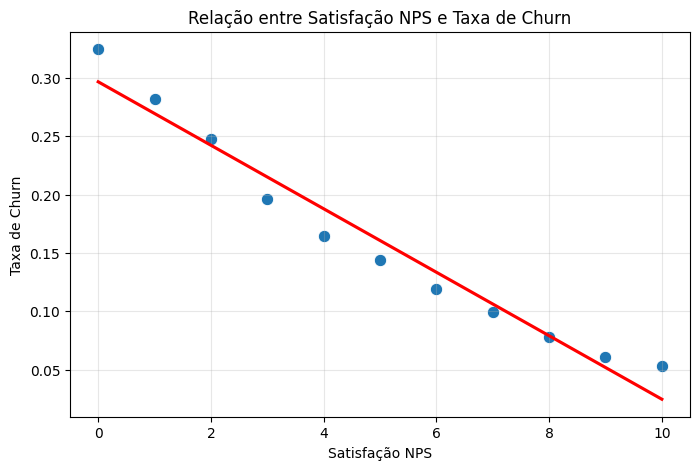

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Taxa de churn por valor de NPS
taxa = (
    df.groupby('satisfacao_nps')['churned']
      .mean()
      .reset_index()
)

plt.figure(figsize=(8,5))

# Pontos observados
sns.scatterplot(
    data=taxa,
    x='satisfacao_nps',
    y='churned',
    s=80
)

# Linha de tendência linear
sns.regplot(
    data=taxa,
    x='satisfacao_nps',
    y='churned',
    scatter=False,
    ci=None,
    color='red'
)

plt.xlabel('Satisfação NPS')
plt.ylabel('Taxa de Churn')
plt.title('Relação entre Satisfação NPS e Taxa de Churn')
plt.grid(alpha=0.3)
plt.show()

In [10]:
df.columns

Index(['id_cliente', 'churned', 'num_apolices_ativas', 'tipo_cobertura',
       'valor_premio_anual', 'tempo_cliente_dias', 'num_produtos_contratados',
       'valor_cobertura_total', 'franquia_media', 'canal_aquisicao',
       'pagamento_em_dia', 'desconto_aplicado_pct', 'metodo_pagamento',
       'score_engajamento_digital', 'indicou_clientes',
       'renovacoes_consecutivas', 'indice_relacionamento', 'tipo_veiculo',
       'ano_veiculo', 'km_anual_estimado', 'segmento_marketing',
       'regiao_vendas', 'ultimo_login_portal_dias', 'score_propensao_churn',
       'cluster_sugerido_crm', 'nunca_logou', 'idade', 'genero',
       'estado_civil', 'tem_filhos', 'qtd_dependentes', 'escolaridade',
       'renda_anual', 'possui_imovel', 'valor_imovel', 'tempo_residencia_anos',
       'num_reclamacoes_12m', 'num_sinistros_historico', 'dias_ultimo_contato',
       'canal_preferencial_contato', 'tempo_medio_resposta_dias',
       'num_ligacoes_suporte_12m', 'tempo_resolucao_ultimo_sinistro',
 

Analyzing client profiles and clusters

In [6]:
df_cluster = df.copy()
colunas_filtro = ['score_engajamento_digital', 'valor_premio_anual', 'tempo_cliente_dias']
for col in colunas_filtro:
    if col in df_cluster.columns:
        df_cluster = df_cluster[df_cluster[col] >= 0]

# Adicionando um leve ruído (jitter) apenas visual ao score para que os pontos não fiquem 100% sobrepostos
df_cluster['score_engajamento_jitter'] = df_cluster['score_engajamento_digital'] + np.random.normal(0, 2, size=len(df_cluster))

In [5]:
df.columns

Index(['id_cliente', 'churned', 'num_apolices_ativas', 'tipo_cobertura',
       'valor_premio_anual', 'tempo_cliente_dias', 'num_produtos_contratados',
       'valor_cobertura_total', 'franquia_media', 'canal_aquisicao',
       'pagamento_em_dia', 'desconto_aplicado_pct', 'metodo_pagamento',
       'score_engajamento_digital', 'indicou_clientes',
       'renovacoes_consecutivas', 'indice_relacionamento', 'tipo_veiculo',
       'ano_veiculo', 'km_anual_estimado', 'segmento_marketing',
       'regiao_vendas', 'ultimo_login_portal_dias', 'score_propensao_churn',
       'cluster_sugerido_crm', 'nunca_logou', 'idade', 'genero',
       'estado_civil', 'tem_filhos', 'qtd_dependentes', 'escolaridade',
       'renda_anual', 'possui_imovel', 'valor_imovel', 'tempo_residencia_anos',
       'num_reclamacoes_12m', 'num_sinistros_historico', 'dias_ultimo_contato',
       'canal_preferencial_contato', 'tempo_medio_resposta_dias',
       'num_ligacoes_suporte_12m', 'tempo_resolucao_ultimo_sinistro',
 

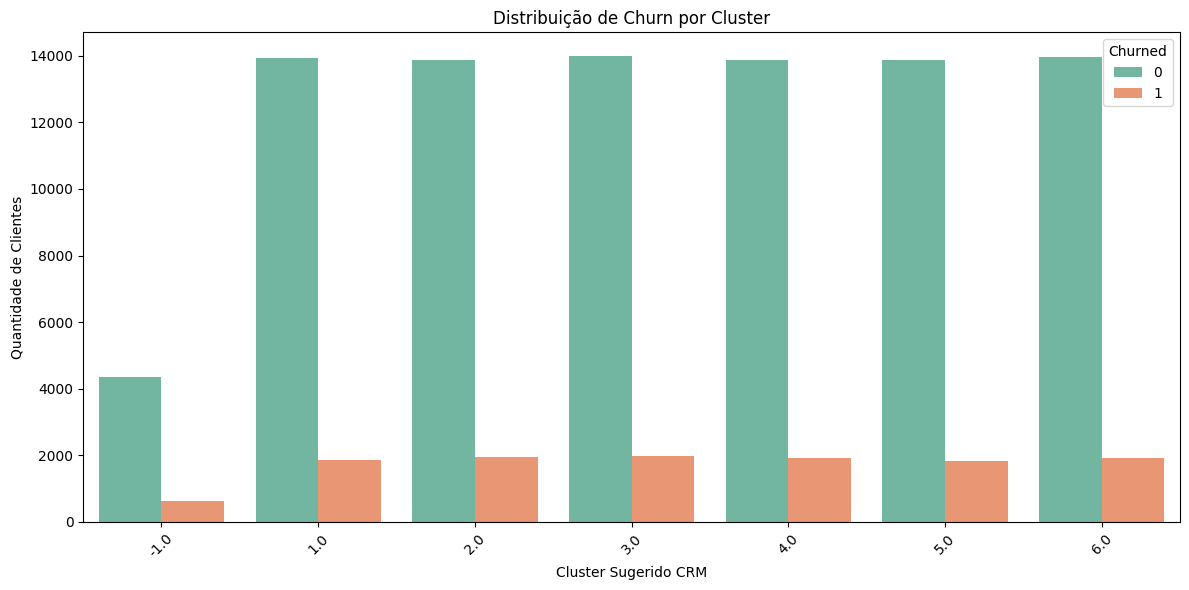

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x="cluster_sugerido_crm",
    hue="churned",
    palette="Set2"
)

plt.title("Distribuição de Churn por Cluster")
plt.xlabel("Cluster Sugerido CRM")
plt.ylabel("Quantidade de Clientes")
plt.xticks(rotation=45)
plt.legend(title="Churned")
plt.tight_layout()
plt.show()

Distribuição bem similar de churn para os clusters sugeridos.

In [8]:
df.columns

Index(['id_cliente', 'churned', 'num_apolices_ativas', 'tipo_cobertura',
       'valor_premio_anual', 'tempo_cliente_dias', 'num_produtos_contratados',
       'valor_cobertura_total', 'franquia_media', 'canal_aquisicao',
       'pagamento_em_dia', 'desconto_aplicado_pct', 'metodo_pagamento',
       'score_engajamento_digital', 'indicou_clientes',
       'renovacoes_consecutivas', 'indice_relacionamento', 'tipo_veiculo',
       'ano_veiculo', 'km_anual_estimado', 'segmento_marketing',
       'regiao_vendas', 'ultimo_login_portal_dias', 'score_propensao_churn',
       'cluster_sugerido_crm', 'nunca_logou', 'idade', 'genero',
       'estado_civil', 'tem_filhos', 'qtd_dependentes', 'escolaridade',
       'renda_anual', 'possui_imovel', 'valor_imovel', 'tempo_residencia_anos',
       'num_reclamacoes_12m', 'num_sinistros_historico', 'dias_ultimo_contato',
       'canal_preferencial_contato', 'tempo_medio_resposta_dias',
       'num_ligacoes_suporte_12m', 'tempo_resolucao_ultimo_sinistro',
 

C:\Users\rafag\AppData\Local\Temp\ipykernel_31536\829330576.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\rafag\AppData\Local\Temp\ipykernel_31536\829330576.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


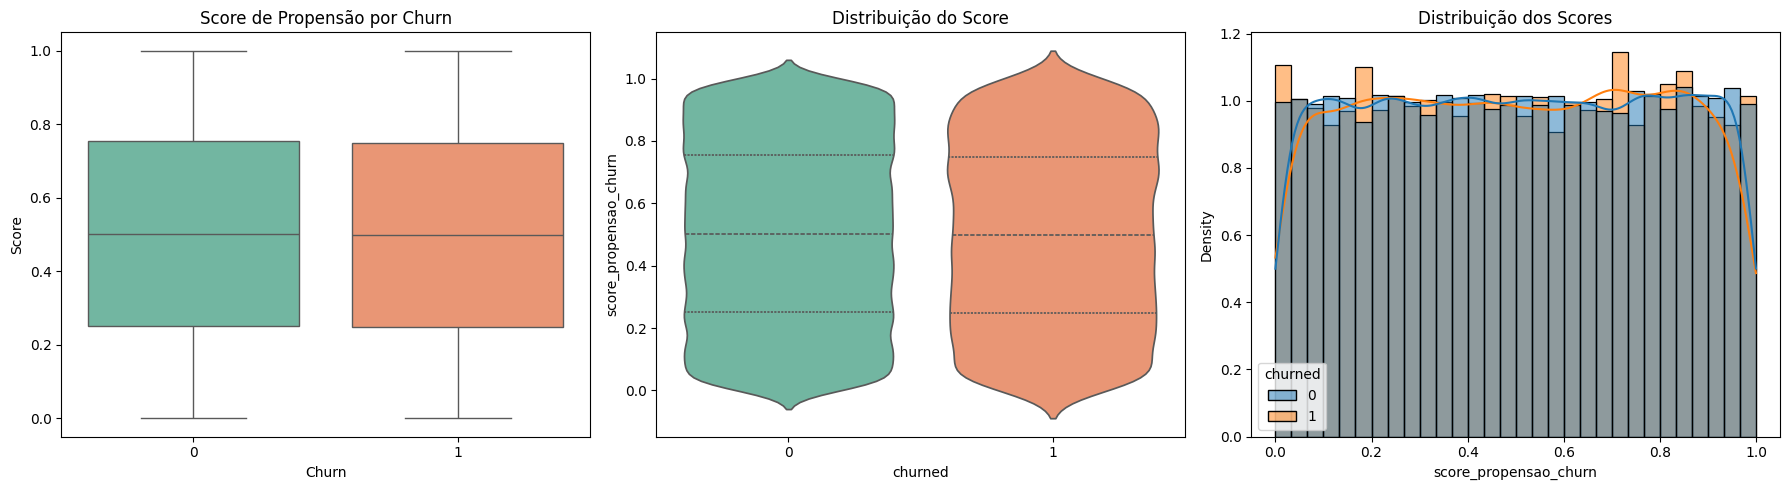

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18,5))

# 1. Boxplot
sns.boxplot(
    data=df,
    x='churned',
    y='score_propensao_churn',
    palette='Set2',
    ax=axes[0]
)
axes[0].set_title('Score de Propensão por Churn')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Score')

# 2. Violinplot
sns.violinplot(
    data=df,
    x='churned',
    y='score_propensao_churn',
    inner='quartile',
    palette='Set2',
    ax=axes[1]
)
axes[1].set_title('Distribuição do Score')

# 3. Histograma
sns.histplot(
    data=df,
    x='score_propensao_churn',
    hue='churned',
    bins=30,
    kde=True,
    stat='density',
    common_norm=False,
    alpha=0.5,
    ax=axes[2]
)
axes[2].set_title('Distribuição dos Scores')

plt.tight_layout()
plt.show()